In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from sklearn.linear_model import LogisticRegression  
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier , GradientBoostingClassifier
from sklearn.model_selection import train_test_split  , cross_validate , RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV , RandomizedSearchCV
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [2]:
IN_KAGGLE = os.path.exists('/kaggle/input')

if IN_KAGGLE :
    DATA_DIR = Path('Multi-Class Prediction of Obesity Risk/')

else:
    DATA_DIR = Path.cwd().parent / 'datasets' / 'processed'

data = pd.read_csv( DATA_DIR / 'final_train.csv' )
data.shape

(20758, 25)

In [3]:
X = data.drop('NObeyesdad' , axis= 1 )
y = data['NObeyesdad']

X.shape , y.shape

((20758, 24), (20758,))

In [4]:
X_train ,X_test, y_train ,   y_test = train_test_split(X , y , test_size=0.20 , random_state=42)

print(f'X_train shape = {X_train.shape}')
print(f'y_train shape = {y_train.shape}')
print(f'X_test shape = {X_test.shape}')
print(f'y_test shape = {y_test.shape}')

X_train shape = (16606, 24)
y_train shape = (16606,)
X_test shape = (4152, 24)
y_test shape = (4152,)


In [ ]:
models = { 'Logistic_Regression' : LogisticRegression() , 
           'Decision_Tree_Classifier': DecisionTreeClassifier(random_state=42) , 
           'Random_Forest_Classifier' : RandomForestClassifier(random_state=42),
           'Gradient_Boosting_Classifier' : GradientBoostingClassifier(random_state=42),
           'XGB_Classifier': XGBClassifier(random_state=42 , ) ,
           'Cat_Boost_Classifier' : CatBoostClassifier(verbose=0 , random_state=42)
          }

In [6]:
models_scores = {}
scores = {'acc' : 'accuracy' , 'f1' : 'f1_macro', 
          'precision': 'precision_macro', 'recall' : 'recall_macro' }

cv = RepeatedStratifiedKFold( n_repeats= 5 , n_splits=5  ,  random_state=42 )

for model_name , model in models.items() :

    cross_validate_model = cross_validate(
                           model , X_train , y_train ,
                           cv= cv , scoring= scores , return_train_score=True )

    models_scores[model_name] = {

        'Train_Accuracy': cross_validate_model['train_acc'].mean() ,
        'Val_Accuracy': cross_validate_model['test_acc'].mean() ,

        'Train_F1' : cross_validate_model['train_f1'].mean() ,
        'Val_F1' : cross_validate_model['test_f1'].mean() ,

        'Train_Precision' : cross_validate_model['train_precision'].mean() ,
        'Val_Precision' : cross_validate_model['test_precision'].mean() ,

        'Train_Recall' : cross_validate_model['train_recall'].mean() ,
        'Val_Recall' : cross_validate_model['test_recall'].mean() ,
   
                                 }
    print(f"{model_name} : Done")
    
models_scores_df = pd.DataFrame( models_scores ).T.sort_values(by='Val_F1', ascending=False)


c:\Users\B-UNIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\B-UNIT\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\B-UNIT\AppData\Lo

Logistic_Regression : Done
Decision_Tree_Classifier : Done
Random_Forest_Classifier : Done
Gradient_Boosting_Classifier : Done
XGB_Classifier : Done
Cat_Boost_Classifier : Done


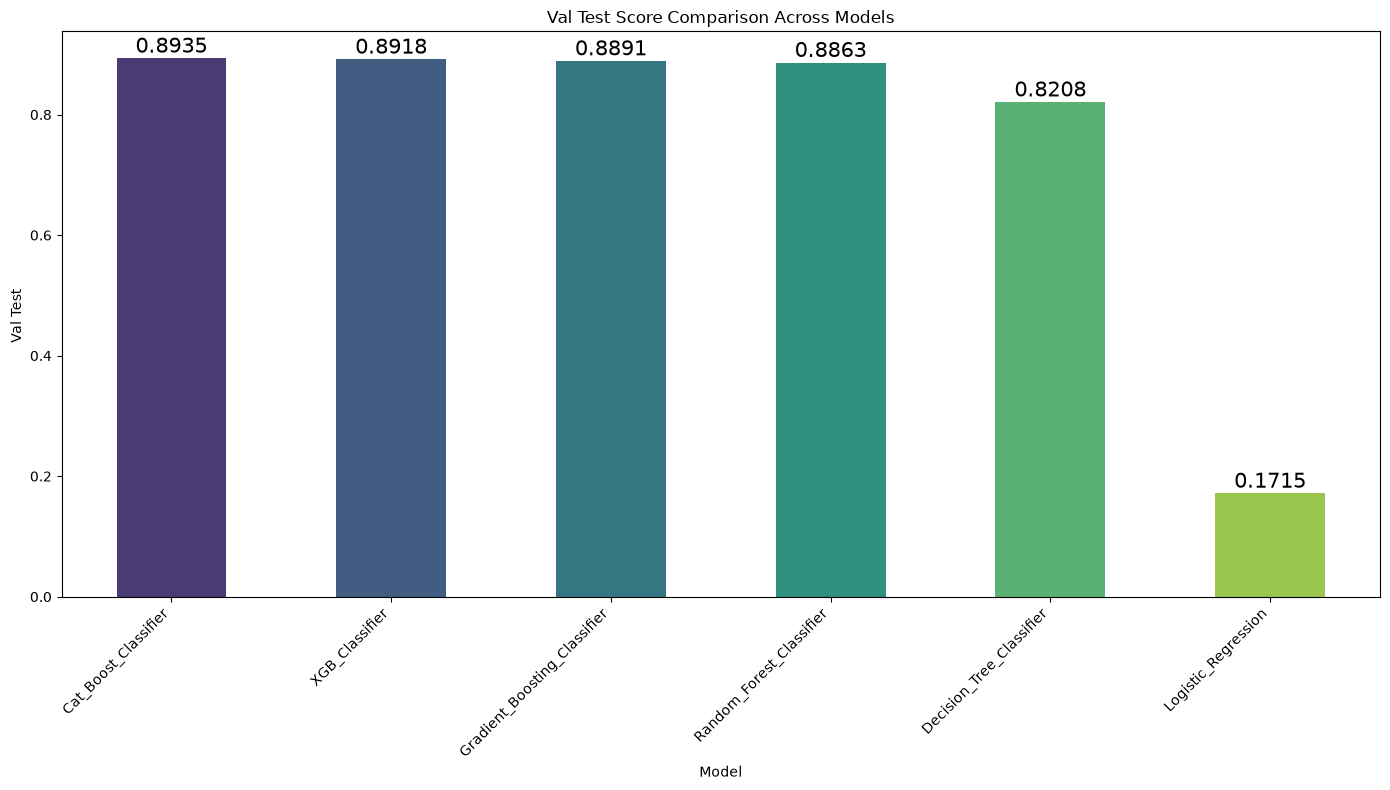

In [7]:

plt.figure( figsize=(14 , 8)) 
sns.barplot( x= models_scores_df.index , y= models_scores_df['Val_F1'] , 
             palette='viridis',hue = models_scores_df.index , legend=False , width = 0.5
           )

for i , v in enumerate( models_scores_df['Val_F1']) :
    plt.text( i , v + 0.001 , f'{v:.4f}', ha='center', va='bottom', fontsize=15)

plt.xlabel('Model')
plt.ylabel('Val Test ')
plt.title('Val Test Score Comparison Across Models')
plt.xticks(rotation = 45 , ha='right')
plt.tight_layout()
plt.show()

### We Will Use 
- Cat_Boost_Classifier
- XGB_Classifier
- Gradient_Boosting_Classifier
- Random_Forest_Classifier

In [8]:
CatBoostClassifier_model = CatBoostClassifier(verbose=0 , random_state= 42)
XGBClassifier_model = XGBClassifier( random_state= 42 )
GradientBoostingClassifier_model = GradientBoostingClassifier(random_state= 42)
RandomForestClassifier_model = RandomForestClassifier(random_state= 42)

best_models ={ 
            'Cat_Boost_Classifier' : CatBoostClassifier_model ,
            'XGB_Classifier' : XGBClassifier_model ,
            'Gradient_Boosting_Classifier': GradientBoostingClassifier_model ,
            'Random_Forest_Classifier': RandomForestClassifier_model
            }

In [9]:
best_params = {
    'Cat_Boost_Classifier': {
        'iterations': [200, 500, 800],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 6, 8],
        'l2_leaf_reg': [1, 3, 5, 7],
        'border_count': [32, 64, 128]
                             },

    'XGB_Classifier': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'subsample': [0.7, 0.8, 1.0],
        'colsample_bytree': [0.7, 0.8, 1.0],
        'gamma': [0, 0.1, 0.3]
                       },

    'Gradient_Boosting_Classifier': {
        'n_estimators': [100, 300, 500],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'subsample': [0.8, 0.9, 1.0]
                                     },

    'Random_Forest_Classifier': {
        'n_estimators': [100, 300, 500],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
                                 }
}

In [ ]:
from sklearn.model_selection import StratifiedKFold

fitted_models = {}
cv_search = StratifiedKFold(n_splits= 3 , shuffle=True , random_state=42 )

for model_name , model in best_models.items():

    RandomizedSearchCV_model = RandomizedSearchCV( 
        model , best_params[model_name] , 
        n_iter= 80 , n_jobs= -1 , cv = cv_search ,
        scoring= 'f1_macro' , return_train_score=True , random_state=42
                                                  )

    RandomizedSearchCV_model.fit( X_train , y_train )

    fitted_models[model_name] = RandomizedSearchCV_model

    print(f'\n{model_name} - Best Score = { RandomizedSearchCV_model.best_score_}')
    print(f'{model_name} - Best params = { RandomizedSearchCV_model.best_params_}\n{"-" *50}\n')

     


Cat_Boost_Classifier - Best Score = 0.893314466880537
Cat_Boost_Classifier - Best params = {'learning_rate': 0.1, 'l2_leaf_reg': 5, 'iterations': 800, 'depth': 6, 'border_count': 128}
--------------------------------------------------


XGB_Classifier - Best Score = 0.8955633082003182
XGB_Classifier - Best params = {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 1.0}
--------------------------------------------------


Gradient_Boosting_Classifier - Best Score = 0.8927143745292495
Gradient_Boosting_Classifier - Best params = {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1}
--------------------------------------------------


Random_Forest_Classifier - Best Score = 0.8861455358682857
Random_Forest_Classifier - Best params = {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30}
---------------

In [11]:
best_Cat_Boost_Classifier = fitted_models['Cat_Boost_Classifier'].best_estimator_

best_XGB_Classifier  = fitted_models['XGB_Classifier'].best_estimator_

best_Gradient_Boosting_Classifier = fitted_models['Gradient_Boosting_Classifier'].best_estimator_

best_Random_Forest_Classifier  = fitted_models['Random_Forest_Classifier'].best_estimator_

In [12]:
import joblib as jb

MODELS_DIR = Path.cwd().parent / 'models'
MODELS_DIR.mkdir( parents= True , exist_ok= True)

trained_models = { 'Cat_Boost_Classifier' : best_Cat_Boost_Classifier ,
                   'XGB_Classifier' : best_XGB_Classifier , 
                   'Gradient_Boosting_Classifier' : best_Gradient_Boosting_Classifier ,
                   'Random_Forest_Classifier' : best_Random_Forest_Classifier
                 }

for model_name , model in trained_models.items():
    jb.dump( model , MODELS_DIR / f'{model_name}_model.pkl')

    print(f'Saved : {model_name}_model.pkl')

Saved : Cat_Boost_Classifier_model.pkl
Saved : XGB_Classifier_model.pkl
Saved : Gradient_Boosting_Classifier_model.pkl
Saved : Random_Forest_Classifier_model.pkl


### we will use <> XGB_Classifier

### Evaluate the Model

In [13]:
y_test = y_test.values
y_test[:5]

array([4, 5, 2, 3, 0])

In [14]:
y_pred = best_XGB_Classifier.predict( X_test )
print(f'y_pred[:20] = {y_pred[:20]}')
print(f'y_test[:20] = {y_test[:20]}')

y_pred[:20] = [4 5 2 3 0 0 4 3 4 6 0 0 3 0 6 5 5 5 6 1]
y_test[:20] = [4 5 2 3 0 0 4 3 4 5 0 0 3 0 6 1 5 1 6 1]


Confusion Matrix 
[[493  28   0   0   0   2   1]
 [ 26 556   0   0   0  37   7]
 [  2   1 474   9   2  14  41]
 [  0   0  13 639   3   0   2]
 [  0   0   0   1 802   0   1]
 [  1  38   9   0   0 384  52]
 [  0   7  33   4   0  51 419]]


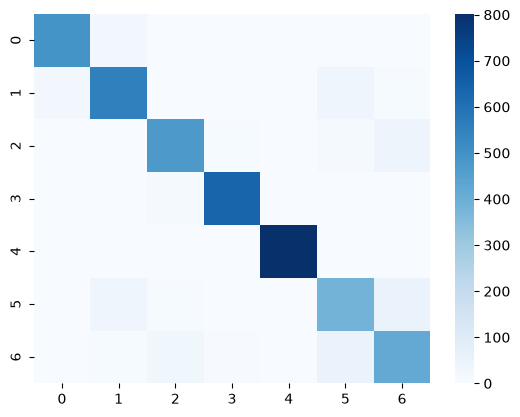

In [15]:
from sklearn.metrics import confusion_matrix , classification_report

cm = confusion_matrix( y_test , y_pred )
print(f'Confusion Matrix \n{cm}')

sns.heatmap(cm , cmap='Blues')
plt.show()

In [16]:
from sklearn.metrics import roc_auc_score , accuracy_score

acc = accuracy_score(y_test , y_pred )
print(f'Accuracy = {acc}')

y_proba = best_XGB_Classifier.predict_proba( X_test )
auc = roc_auc_score( y_test , y_proba, multi_class='ovr' , average='macro')
print(f'     AUC = {auc}')

Accuracy = 0.9072736030828517
     AUC = 0.9898884397375693


In [17]:
report = classification_report(y_test , y_pred , output_dict=True)
report = pd.DataFrame ( report ).T
report

,precision,recall,f1-score,support
0,0.944444,0.940840,0.942639,524.000000
1,0.882540,0.888179,0.885350,626.000000
2,0.896030,0.872928,0.884328,543.000000
3,0.978560,0.972603,0.975573,657.000000
4,0.993804,0.997512,0.995655,804.000000
5,0.786885,0.793388,0.790123,484.000000
6,0.801147,0.815175,0.808100,514.000000
accuracy,0.907274,0.907274,0.907274,0.907274
macro avg,0.897630,0.897232,0.897395,4152.000000
weighted avg,0.907630,0.907274,0.907419,4152.000000
